<a href="https://colab.research.google.com/github/fahmidafairooz/drone-detection/blob/main/Technical_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Verify the folder is visible

In [20]:
!ls "/content/drive/MyDrive/archive"

VisDrone_Dataset


 Copy to Colab's local disk

In [24]:
!cp -r "/content/drive/MyDrive/archive" /content/VisDrone_Dataset
!ls /content/VisDrone_Dataset

archive				 VisDrone2019-DET-train
VisDrone2019-DET-test-challenge  VisDrone2019-DET-val
VisDrone2019-DET-test-dev	 visdrone.yaml


Cell 4 — Verify everything is in place

In [25]:
import os, glob
base = '/content/VisDrone_Dataset'
for split in ['train', 'val', 'test-dev']:
    img_dir = f'{base}/VisDrone2019-DET-{split}/images'
    lbl_dir = f'{base}/VisDrone2019-DET-{split}/labels'
    n_img = len(glob.glob(f'{img_dir}/*.jpg'))
    n_lbl = len(glob.glob(f'{lbl_dir}/*.txt'))
    print(f"{split:10s}: {n_img:5d} images, {n_lbl:5d} labels")

train     :  6471 images,  3788 labels
val       :   548 images,   548 labels
test-dev  :  1610 images,  1610 labels


In [26]:
# Clear out any partial copy from before
!rm -rf /content/VisDrone_Dataset

# Copy from the correct nested path (note the extra /VisDrone_Dataset)
print("Copying ~2.26 GB from Drive — this takes 5-10 minutes. Please wait...")
!cp -r "/content/drive/MyDrive/archive/VisDrone_Dataset" /content/VisDrone_Dataset
print("✅ Copy complete!")

# Verify
!ls /content/VisDrone_Dataset

Copying ~2.26 GB from Drive — this takes 5-10 minutes. Please wait...
✅ Copy complete!
VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val


In [27]:
import os, glob
base = '/content/VisDrone_Dataset'
for split in ['train', 'val', 'test-dev']:
    img_dir = f'{base}/VisDrone2019-DET-{split}/images'
    lbl_dir = f'{base}/VisDrone2019-DET-{split}/labels'
    n_img = len(glob.glob(f'{img_dir}/*.jpg'))
    n_lbl = len(glob.glob(f'{lbl_dir}/*.txt'))
    print(f"{split:10s}: {n_img:5d} images, {n_lbl:5d} labels")

train     :  6471 images,  6471 labels
val       :   548 images,   548 labels
test-dev  :  1610 images,  1610 labels


Cell A — Install & check GPU (30 sec)

In [28]:
!pip install ultralytics -q
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "❌ NO GPU")

GPU: ❌ NO GPU


verifying if the GPU is active

In [1]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "❌ STILL NO GPU")

GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset from Drive — 5-10 min, please wait...")
!cp -r "/content/drive/MyDrive/archive/VisDrone_Dataset" /content/VisDrone_Dataset
print("✅ Copy complete!")

# Verify counts
import glob
for split in ['train', 'val', 'test-dev']:
    n = len(glob.glob(f'/content/VisDrone_Dataset/VisDrone2019-DET-{split}/images/*.jpg'))
    print(f"{split}: {n} images")

Mounted at /content/drive
Copying dataset from Drive — 5-10 min, please wait...
cp: cannot open '/content/drive/MyDrive/archive/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000253.jpg' for reading: Software caused connection abort
cp: cannot stat '/content/drive/MyDrive/archive/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000231.jpg': No such file or directory
cp: cannot stat '/content/drive/MyDrive/archive/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000252.jpg': No such file or directory
cp: cannot stat '/content/drive/MyDrive/archive/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000234.jpg': No such file or directory
cp: cannot stat '/content/drive/MyDrive/archive/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000257.jpg': No such file or directory
cp: cannot stat '/content/drive/MyDrive/archive/VisDrone_Dataset/VisDrone2019-DET-test-challenge/imag

Cell 3 — Install ultralytics

In [3]:
!pip install ultralytics -q
import torch
print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.8 MB/s eta 0:00:00
GPU: Tesla T4


Cell A — Re-copy dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset from Drive — 5-10 min, please wait...")
!cp -r "/content/drive/MyDrive/archive/VisDrone_Dataset" /content/VisDrone_Dataset
print("✅ Copy complete!")

import glob
for split in ['train', 'val', 'test-dev']:
    n = len(glob.glob(f'/content/VisDrone_Dataset/VisDrone2019-DET-{split}/images/*.jpg'))
    print(f"{split}: {n} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying dataset from Drive — 5-10 min, please wait...
✅ Copy complete!
train: 0 images
val: 0 images
test-dev: 0 images


Cell B — Write YAML + make output folders

In [6]:
yaml_content = """path: /content/VisDrone_Dataset
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""
with open('/content/visdrone.yaml', 'w') as f:
    f.write(yaml_content)

import os
os.makedirs('/content/outputs', exist_ok=True)
os.makedirs('/content/outputs/predictions', exist_ok=True)
print("Ready")

Ready


Cell C
 Task 1: Sample visualizations

In [13]:
import os, glob

# Check what's actually in /content/
print("=== /content/ ===")
!ls /content/

print("\n=== /content/VisDrone_Dataset/ (if exists) ===")
!ls /content/VisDrone_Dataset/ 2>/dev/null || echo "❌ Folder doesn't exist"

print("\n=== Looking for train images ===")
patterns = [
    '/content/VisDrone_Dataset/VisDrone2019-DET-train/images/*.jpg',
    '/content/VisDrone_Dataset/VisDrone2019-DET-train/images/*.JPG',
    '/content/VisDrone_Dataset/VisDrone2019-DET-train/*.jpg',
]
for p in patterns:
    print(f"  {p}: {len(glob.glob(p))} files")

=== /content/ ===
drive  outputs	sample_data  VisDrone_Dataset  visdrone.yaml

=== /content/VisDrone_Dataset/ (if exists) ===
VisDrone2019-DET-test-challenge  VisDrone_Dataset  visdrone.yaml

=== Looking for train images ===
  /content/VisDrone_Dataset/VisDrone2019-DET-train/images/*.jpg: 0 files
  /content/VisDrone_Dataset/VisDrone2019-DET-train/images/*.JPG: 0 files
  /content/VisDrone_Dataset/VisDrone2019-DET-train/*.jpg: 0 files


In [14]:
# Step 1: Wipe whatever partial mess exists
!rm -rf /content/VisDrone_Dataset
print("Old folder removed.")

# Step 2: Check the actual structure inside your Drive folder
print("\n=== What's inside Drive/archive/ ===")
!ls "/content/drive/MyDrive/archive/"

print("\n=== What's inside Drive/archive/VisDrone_Dataset/ ===")
!ls "/content/drive/MyDrive/archive/VisDrone_Dataset/"

Old folder removed.

=== What's inside Drive/archive/ ===
VisDrone_Dataset

=== What's inside Drive/archive/VisDrone_Dataset/ ===
VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val


In [15]:
print("Copying ~2.26 GB — this takes 8-10 min. DO NOT interrupt.")
print("You'll see no output until it's done. That's normal.\n")

!cp -r "/content/drive/MyDrive/archive/VisDrone_Dataset/." /content/VisDrone_Dataset/

print("✅ Copy command finished!")

# Verify
import glob
print("\n=== Verification ===")
for split in ['train', 'val', 'test-dev']:
    n_img = len(glob.glob(f'/content/VisDrone_Dataset/VisDrone2019-DET-{split}/images/*.jpg'))
    n_lbl = len(glob.glob(f'/content/VisDrone_Dataset/VisDrone2019-DET-{split}/labels/*.txt'))
    print(f"{split:10s}: {n_img:5d} images, {n_lbl:5d} labels")

Copying ~2.26 GB — this takes 8-10 min. DO NOT interrupt.
You'll see no output until it's done. That's normal.

✅ Copy command finished!

=== Verification ===
train     :  6471 images,  6471 labels
val       :   548 images,   548 labels
test-dev  :  1610 images,  1610 labels


Cell B — YAML + output folders

In [17]:
yaml_content = """path: /content/VisDrone_Dataset
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""
with open('/content/visdrone.yaml', 'w') as f:
    f.write(yaml_content)

import os
os.makedirs('/content/outputs', exist_ok=True)
os.makedirs('/content/outputs/predictions', exist_ok=True)
print(" Ready")

 Ready


Cell C — Task 1: Sample visualizations

Found 6471 training images


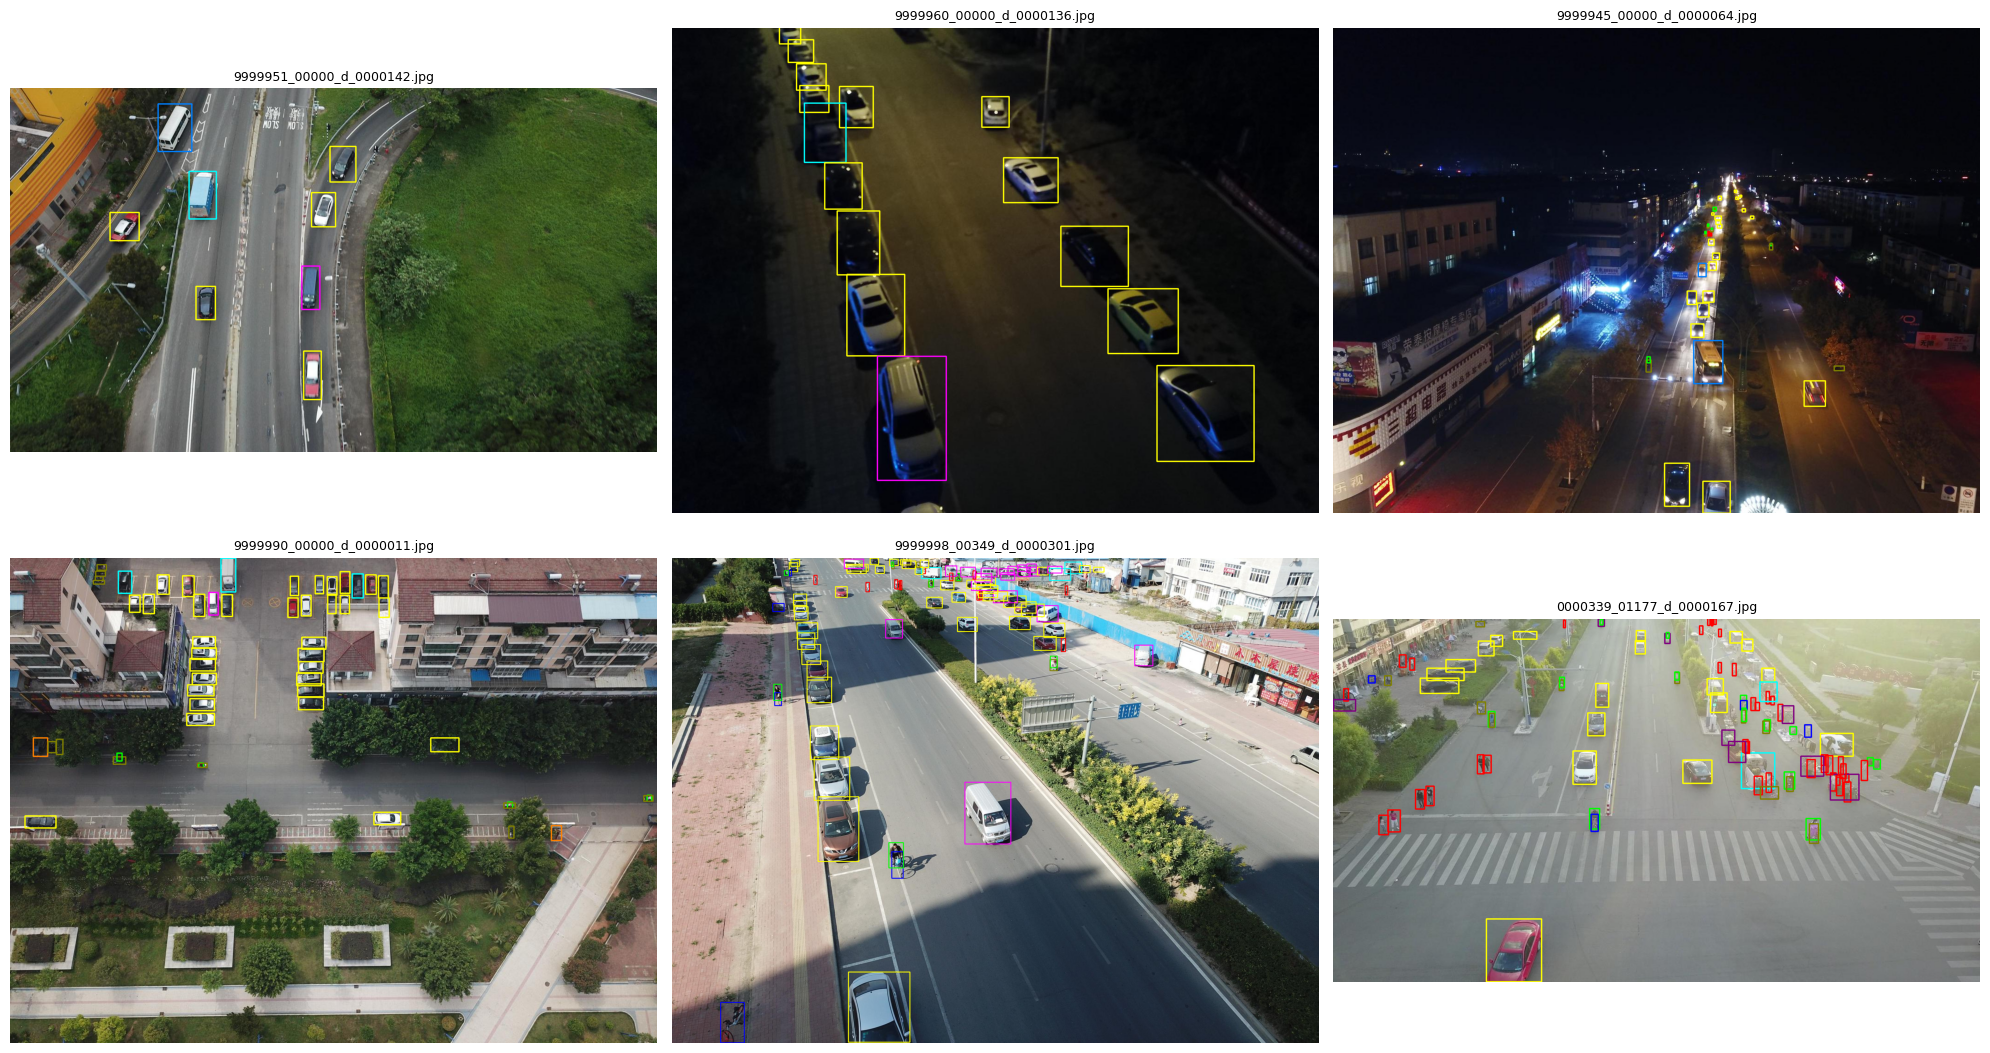

✅ Saved dataset_samples.png


In [18]:
import glob, cv2, random, os
import matplotlib.pyplot as plt

CLASS_NAMES = ['pedestrian','people','bicycle','car','van','truck',
               'tricycle','awning-tricycle','bus','motor']
COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),
          (0,255,255),(128,0,128),(255,128,0),(0,128,255),(128,128,0)]

img_paths = glob.glob('/content/VisDrone_Dataset/VisDrone2019-DET-train/images/*.jpg')
print(f"Found {len(img_paths)} training images")
random.seed(42)
sample_paths = random.sample(img_paths, 6)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, p in zip(axes.flat, sample_paths):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = p.replace('/images/', '/labels/').replace('.jpg', '.txt')
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            parts = line.split()
            if len(parts) < 5: continue
            c = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1, y1 = int((cx-bw/2)*w), int((cy-bh/2)*h)
            x2, y2 = int((cx+bw/2)*w), int((cy+bh/2)*h)
            cv2.rectangle(img, (x1,y1), (x2,y2), COLORS[c], 2)
    ax.imshow(img); ax.set_title(os.path.basename(p), fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig('/content/outputs/dataset_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved dataset_samples.png")

Cell D — Task 1: Class distribution

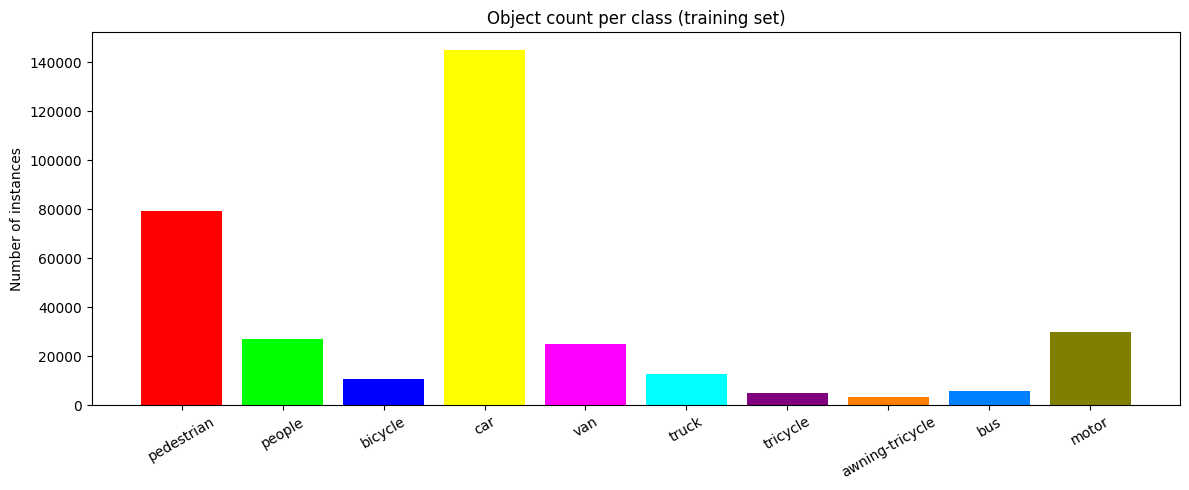


Class counts:
  pedestrian              79337
  people                  27059
  bicycle                 10480
  car                    144867
  van                     24956
  truck                   12875
  tricycle                 4812
  awning-tricycle          3246
  bus                      5926
  motor                   29647


In [19]:
from collections import Counter
counts = Counter()
for lbl in glob.glob('/content/VisDrone_Dataset/VisDrone2019-DET-train/labels/*.txt'):
    for line in open(lbl):
        parts = line.split()
        if parts: counts[int(parts[0])] += 1

plt.figure(figsize=(12,5))
classes = sorted(counts.keys())
plt.bar([CLASS_NAMES[c] for c in classes], [counts[c] for c in classes],
        color=[tuple(x/255 for x in COLORS[c]) for c in classes])
plt.title('Object count per class (training set)')
plt.xticks(rotation=30); plt.ylabel('Number of instances')
plt.tight_layout()
plt.savefig('/content/outputs/class_distribution.png', dpi=100)
plt.show()

print("\nClass counts:")
for c in classes:
    print(f"  {CLASS_NAMES[c]:20s} {counts[c]:>8d}")

Cell E — Task 2: TRAIN THE MODEL

In [20]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/visdrone.yaml',
    epochs=15,
    imgsz=640,
    batch=16,
    name='visdrone_run',
    patience=5,
    plots=True,
    verbose=True
)
print("✅ Training complete!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

Cell F : Copying training plots

=== Training curves ===


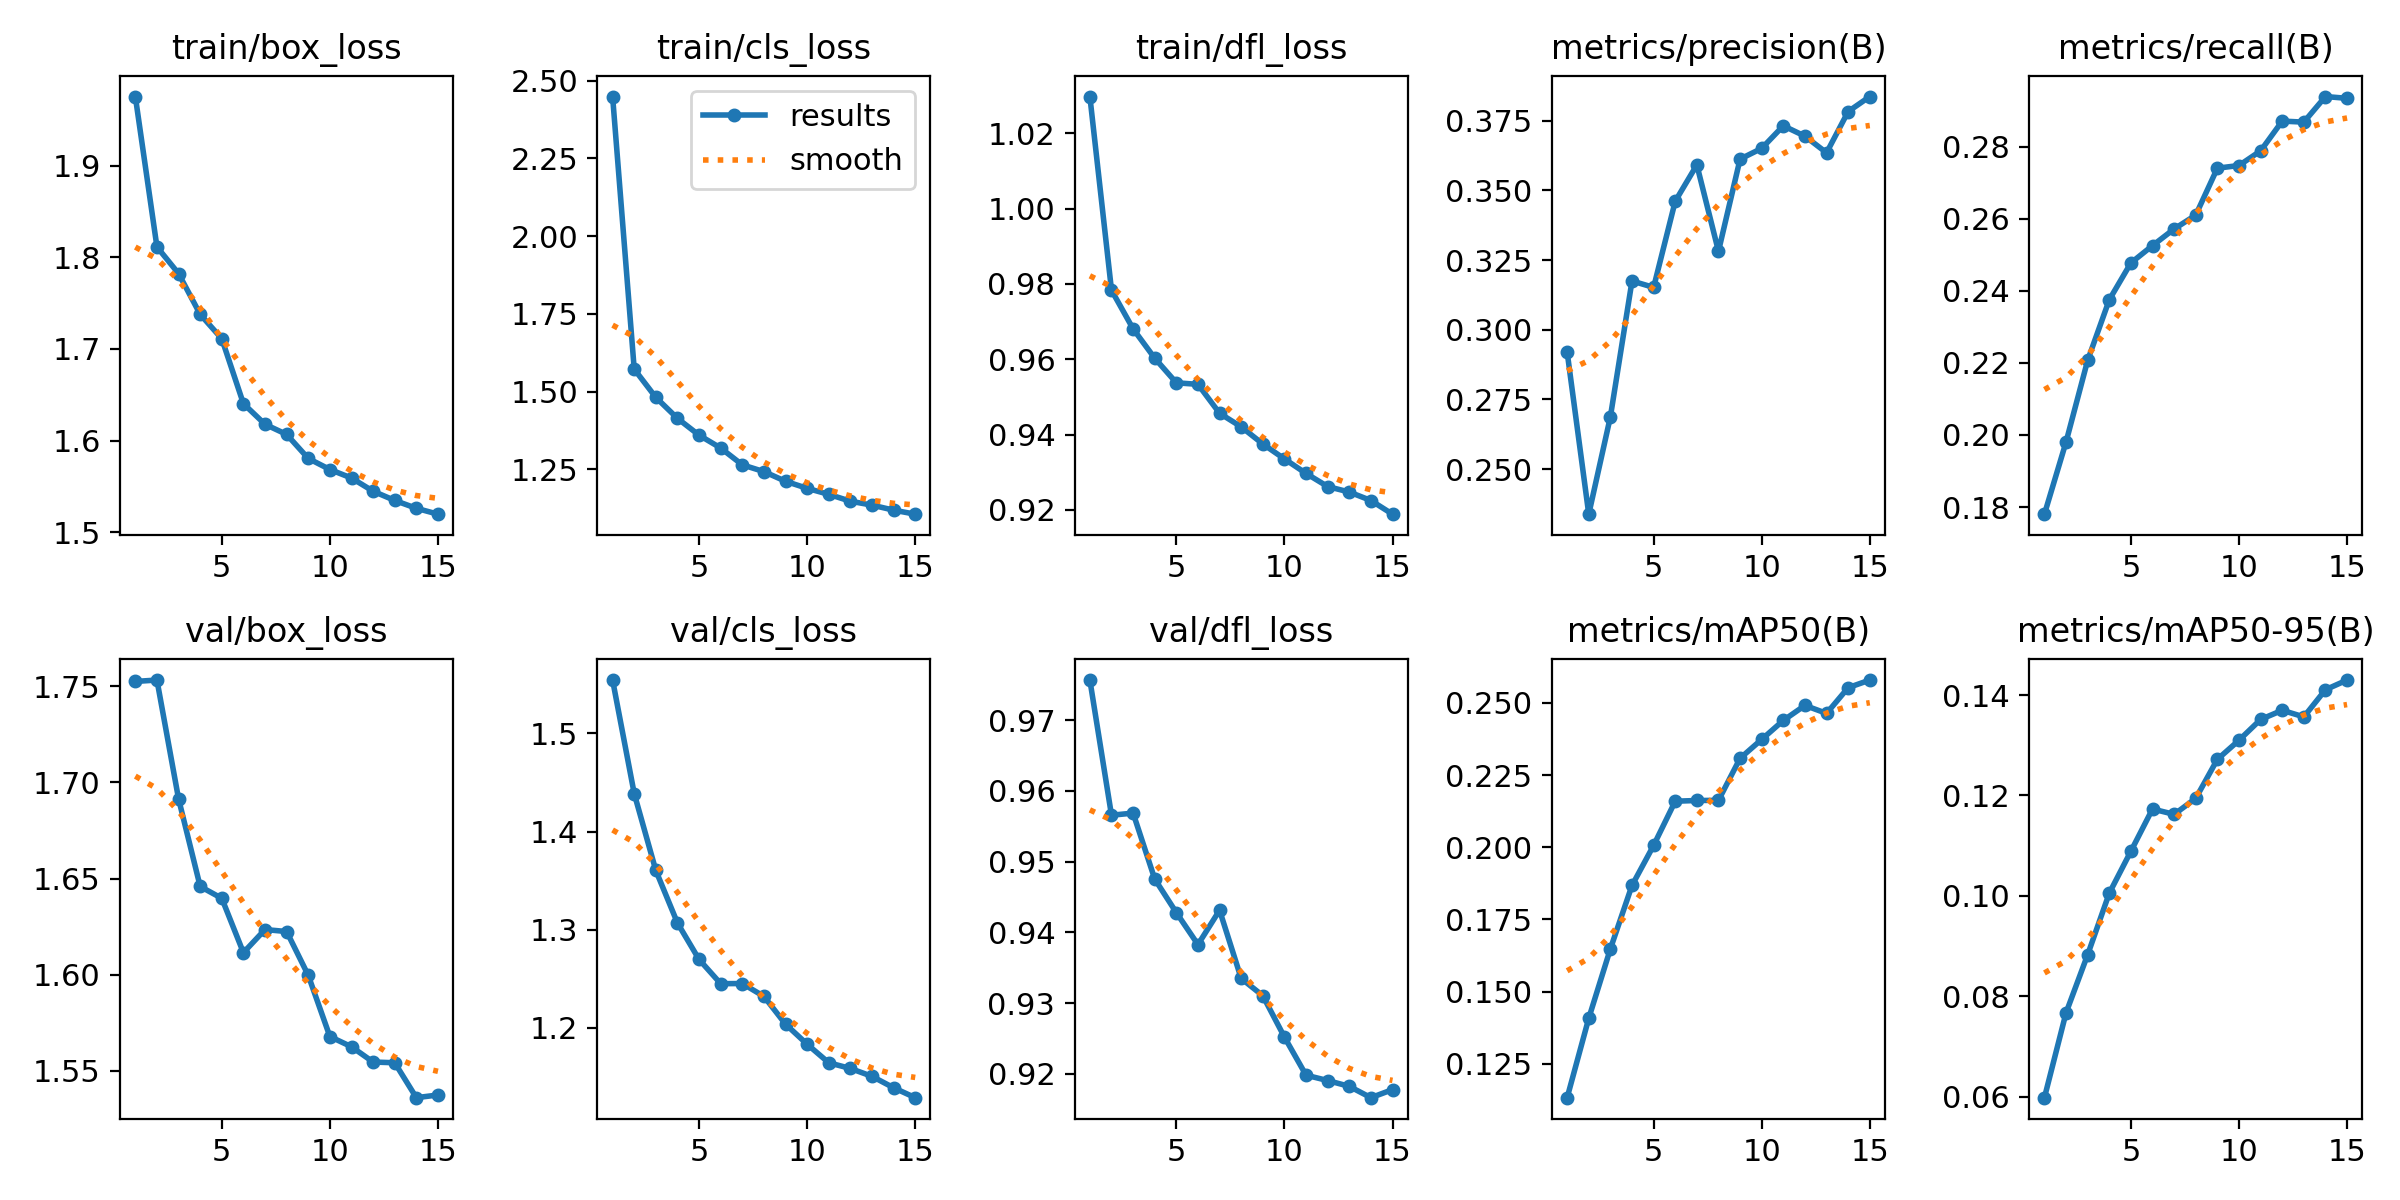


=== Confusion matrix ===


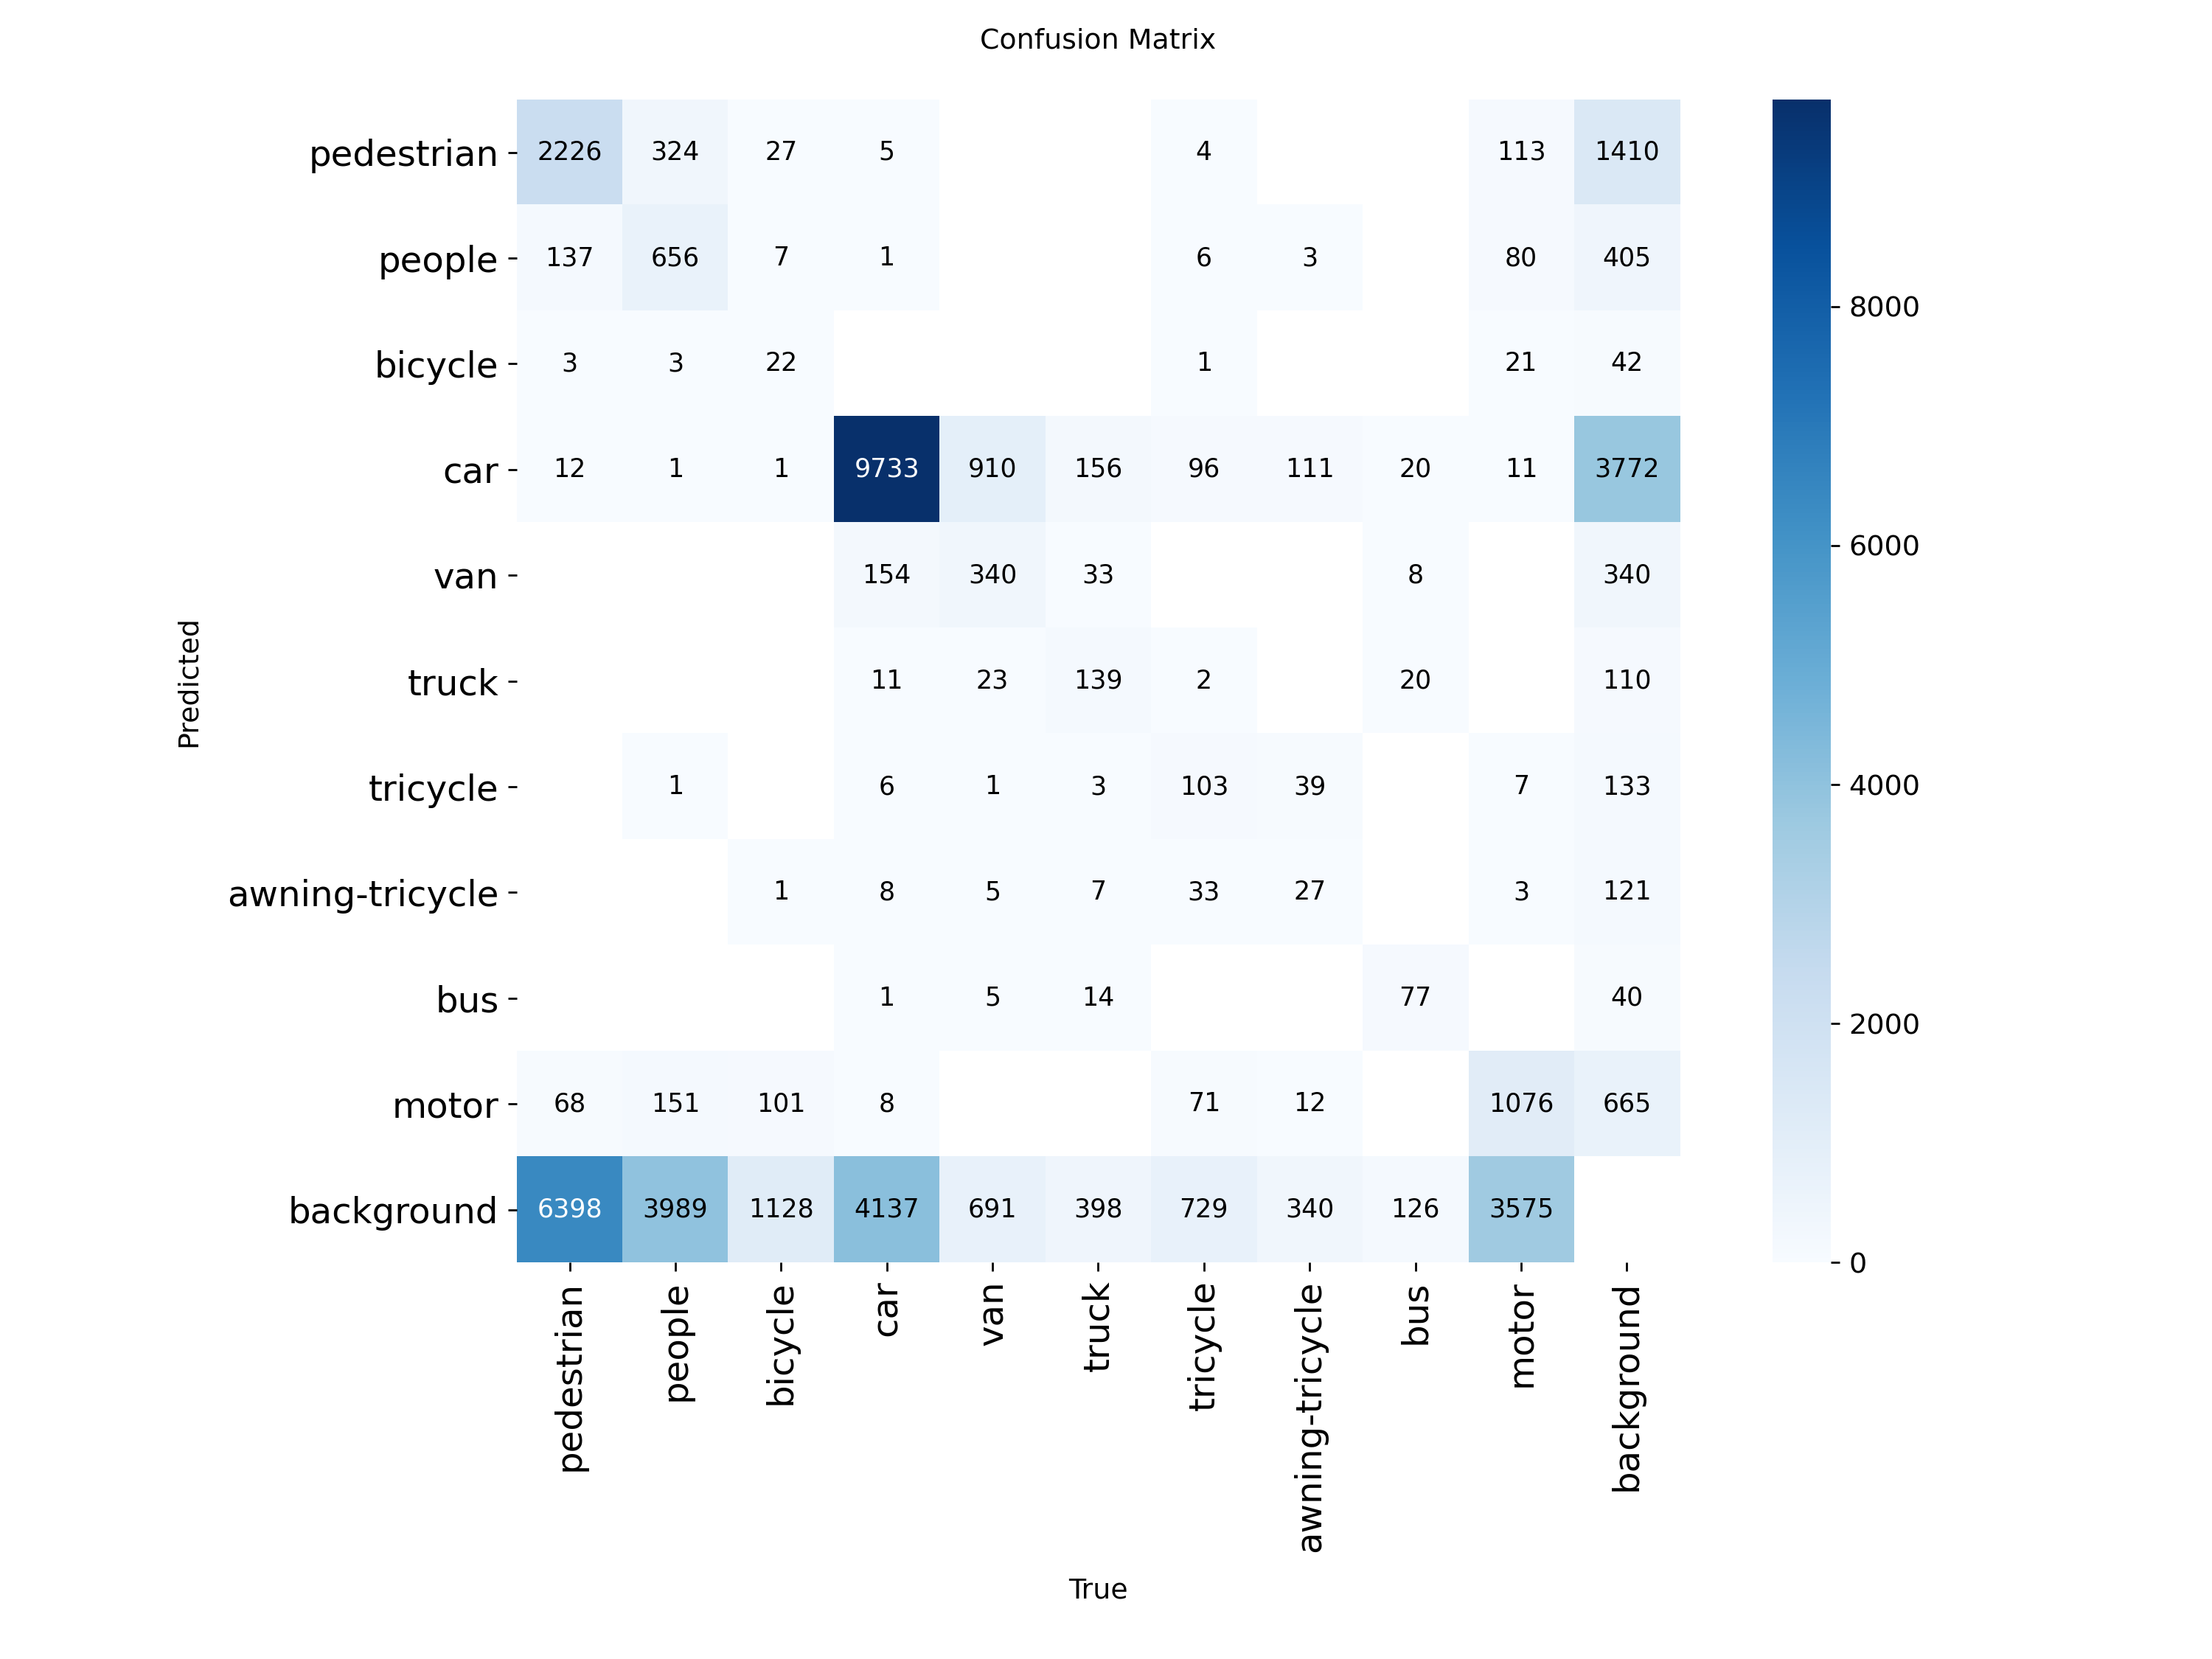

 Plots saved


In [22]:
import os
run_dir = '/content/runs/detect/visdrone_run'
!cp {run_dir}/results.png /content/outputs/training_curves.png
!cp {run_dir}/confusion_matrix.png /content/outputs/confusion_matrix.png
!cp {run_dir}/PR_curve.png /content/outputs/pr_curve.png 2>/dev/null
!cp {run_dir}/F1_curve.png /content/outputs/f1_curve.png 2>/dev/null
!cp {run_dir}/labels.jpg /content/outputs/dataset_labels.png 2>/dev/null

from IPython.display import Image, display
print("=== Training curves ===")
display(Image('/content/outputs/training_curves.png'))
print("\n=== Confusion matrix ===")
display(Image('/content/outputs/confusion_matrix.png'))
print(" Plots saved")

Cell G — Task 3: Detection + counting

Running detection on 10 test images:

  0000006_00159_d_0000001.jpg     humans=  1  cars= 30
  0000006_00611_d_0000002.jpg     humans=  3  cars= 40
  0000006_01111_d_0000003.jpg     humans=  2  cars= 11
  0000006_01275_d_0000004.jpg     humans=  2  cars= 12
  0000006_01659_d_0000004.jpg     humans=  0  cars=  6
  0000006_02138_d_0000006.jpg     humans=  0  cars=  3
  0000006_02616_d_0000007.jpg     humans=  0  cars=  0
  0000006_03636_d_0000009.jpg     humans=  0  cars=  0
  0000006_04050_d_0000010.jpg     humans=  0  cars=  0
  0000006_04309_d_0000011.jpg     humans=  0  cars=  6


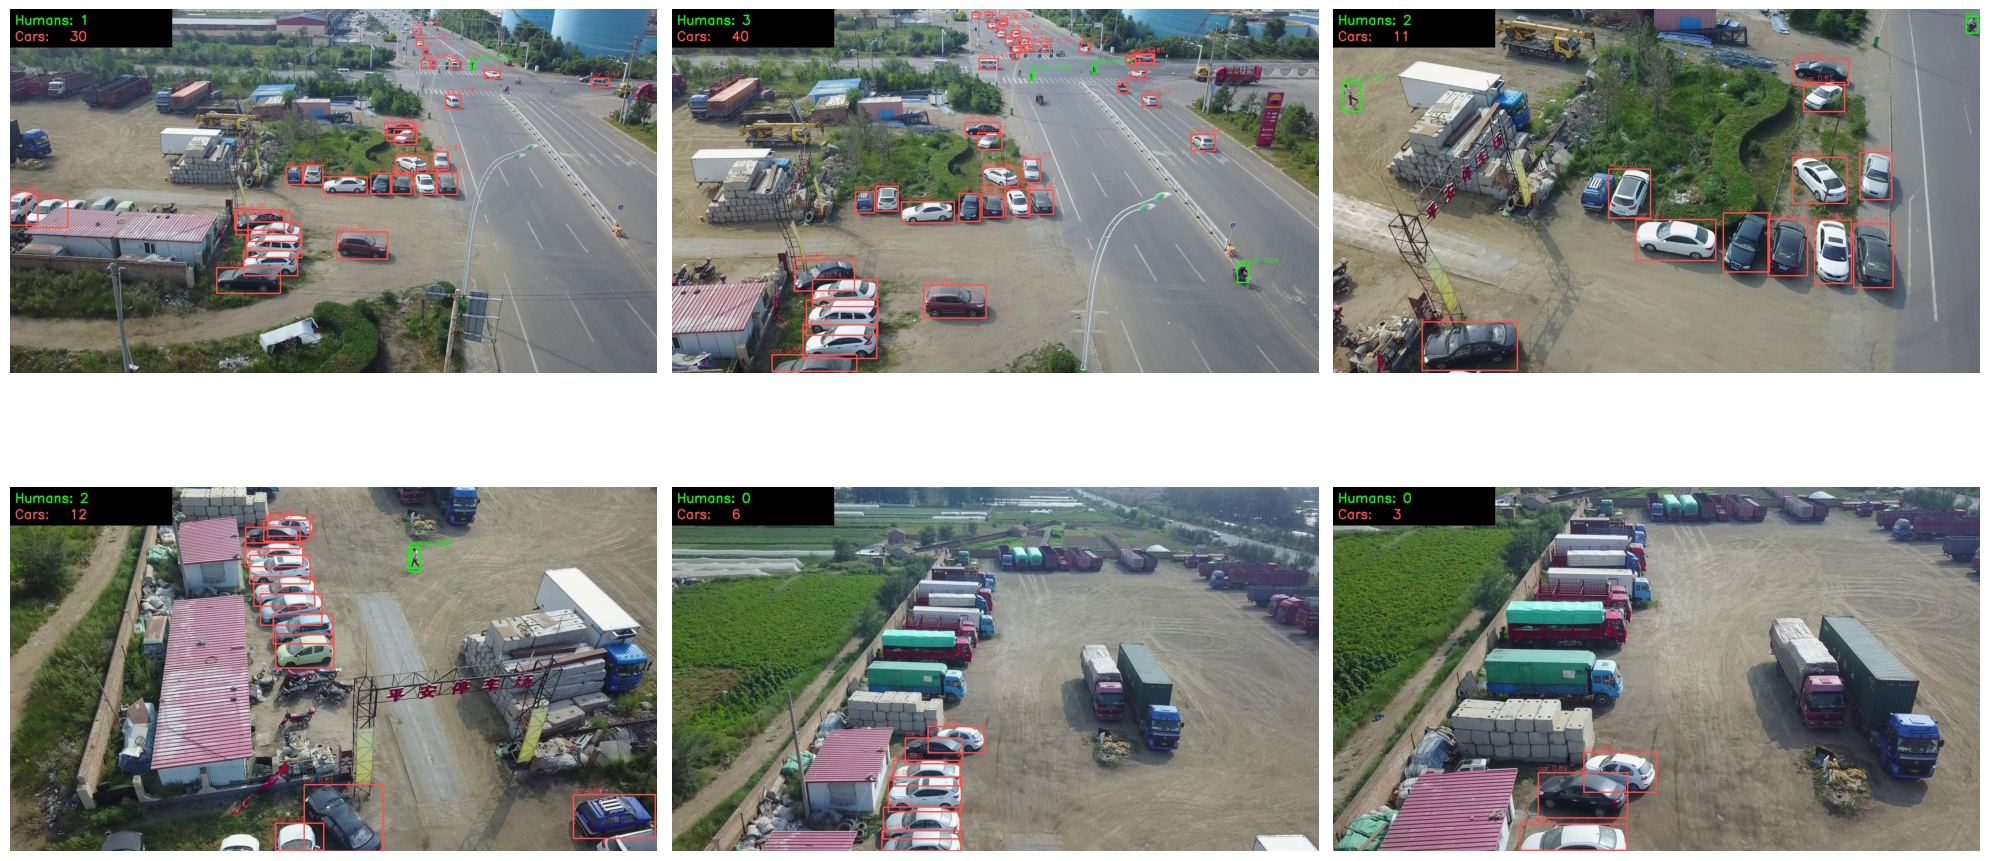

✅ Predictions saved


In [23]:
import numpy as np
import cv2, glob, os
import matplotlib.pyplot as plt
from ultralytics import YOLO

best = YOLO('/content/runs/detect/visdrone_run/weights/best.pt')

def detect_and_count(image_path, save_dir='/content/outputs/predictions', conf=0.25):
    os.makedirs(save_dir, exist_ok=True)
    result = best.predict(source=image_path, conf=conf, verbose=False)[0]

    img = cv2.imread(image_path)
    classes = result.boxes.cls.cpu().numpy().astype(int)
    boxes = result.boxes.xyxy.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    n_humans = int(((classes == 0) | (classes == 1)).sum())
    n_cars = int((classes == 3).sum())

    for (x1,y1,x2,y2), c, cf in zip(boxes, classes, confs):
        if c in [0, 1]:
            color, label = (0,255,0), 'human'
        elif c == 3:
            color, label = (80,80,255), 'car'
        else:
            continue
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, f'{label} {cf:.2f}', (x1, max(y1-5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    cv2.rectangle(img, (0,0), (340, 80), (0,0,0), -1)
    cv2.putText(img, f'Humans: {n_humans}', (10, 32),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)
    cv2.putText(img, f'Cars:   {n_cars}', (10, 66),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (80,80,255), 2)

    out_path = os.path.join(save_dir, os.path.basename(image_path))
    cv2.imwrite(out_path, img)
    return n_humans, n_cars, out_path

test_imgs = sorted(glob.glob(
    '/content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/*.jpg'))[:10]

print("Running detection on 10 test images:\n")
for p in test_imgs:
    h, c, out = detect_and_count(p)
    print(f"  {os.path.basename(p):30s}  humans={h:3d}  cars={c:3d}")

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, p in zip(axes.flat, test_imgs[:6]):
    out = f'/content/outputs/predictions/{os.path.basename(p)}'
    ax.imshow(cv2.cvtColor(cv2.imread(out), cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/outputs/predictions_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Predictions saved")

Cell H — Task 4:( Tracking bonus)

In [25]:
# Build a pseudo-video from sequential test images
imgs = sorted(glob.glob('/content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/*.jpg'))[:60]
sample = cv2.imread(imgs[0])
h, w = sample.shape[:2]
writer = cv2.VideoWriter('/content/sample_video.mp4',
                         cv2.VideoWriter_fourcc(*'mp4v'), 5, (w, h))
for p in imgs:
    img = cv2.resize(cv2.imread(p), (w, h))
    writer.write(img)
writer.release()
print(" Sample video created")

# ByteTrack
results = best.track(
    source='/content/sample_video.mp4',
    tracker='bytetrack.yaml',
    conf=0.25,
    save=True,
    project='/content/outputs',
    name='tracking'
)
print(" Tracking complete")
!ls /content/outputs/tracking/

 Sample video created
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/outputs/tracking-2
 Tracking complete
sample_video.avi


In [26]:
import os
for folder in ['tracking', 'tracking-2', 'tracking-3']:
    path = f'/content/outputs/{folder}'
    if os.path.exists(path):
        print(f"\n=== {path}/ ===")
        !ls -la {path}


=== /content/outputs/tracking/ ===
total 9708
drwxr-xr-x 2 root root    4096 May 16 12:41 .
drwxr-xr-x 5 root root    4096 May 16 12:42 ..
-rw-r--r-- 1 root root 9929528 May 16 12:41 sample_video.avi

=== /content/outputs/tracking-2/ ===
total 9708
drwxr-xr-x 2 root root    4096 May 16 12:42 .
drwxr-xr-x 5 root root    4096 May 16 12:42 ..
-rw-r--r-- 1 root root 9929528 May 16 12:42 sample_video.avi



Cell I — Task 5: Save metrics to file

In [28]:
# Re-run validation to capture clean metric values
metrics = best.val(data='/content/visdrone.yaml', split='val', verbose=False)

import time
N = 20
t0 = time.time()
for _ in range(N):
    _ = best.predict(test_imgs[0], verbose=False)
fps = N / (time.time() - t0)

results_text = f"""=== Final Model Metrics ===
mAP@50      : {metrics.box.map50:.4f}
mAP@50-95   : {metrics.box.map:.4f}
Precision   : {metrics.box.mp:.4f}
Recall      : {metrics.box.mr:.4f}
FPS         : {fps:.1f} on T4 GPU

=== Per-class mAP@50 ===
pedestrian       : 0.263
people           : 0.196
bicycle          : 0.038
car              : 0.686
van              : 0.290
truck            : 0.239
tricycle         : 0.156
awning-tricycle  : 0.0714
bus              : 0.358
motor            : 0.282

=== Training config ===
Model       : YOLOv8n (3.0M params)
Dataset     : VisDrone2019-DET
Epochs      : 15
Image size  : 640
Batch       : 16
Train time  : 40 min on Tesla T4
"""

with open('/content/outputs/metrics.txt', 'w') as f:
    f.write(results_text)
print(results_text)
print(" Metrics saved to metrics.txt")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2534.6±977.9 MB/s, size: 120.8 KB)
val: Scanning /content/VisDrone_Dataset/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 143.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.5it/s 14.0s
                   all        548      38759      0.383      0.294      0.259      0.144
Speed: 1.6ms preprocess, 3.1ms inference, 0.0ms loss, 5.3ms postprocess per image
Results saved to /content/runs/detect/val-2
=== Final Model Metrics ===
mAP@50      : 0.2588
mAP@50-95   : 0.1437
Precision   : 0.3833
Recall      : 0.2944
FPS         : 47.6 on T4 GPU

=== Per-class mAP@50 ===
pedestrian       : 0.263
people           : 0.196
bicycle          : 0.038
car              : 0.686
van              : 0.290
truck            : 0.239
tricycle       

Cell J — Bundle and download

In [30]:
!cp /content/runs/detect/visdrone_run/weights/best.pt /content/outputs/best_model.pt
!ls -la /content/outputs/

!zip -rq /content/visdrone_outputs.zip /content/outputs
!ls -lh /content/visdrone_outputs.zip

from google.colab import files
files.download('/content/visdrone_outputs.zip')
print(" Downloading zip — check your browser's download folder")

total 11832
drwxr-xr-x 5 root root    4096 May 16 12:52 .
drwxr-xr-x 1 root root    4096 May 16 12:52 ..
-rw-r--r-- 1 root root 6224618 May 16 12:52 best_model.pt
-rw-r--r-- 1 root root   37995 May 16 11:47 class_distribution.png
-rw-r--r-- 1 root root  267943 May 16 12:38 confusion_matrix.png
-rw-r--r-- 1 root root  133382 May 16 12:38 dataset_labels.png
-rw-r--r-- 1 root root 2559325 May 16 11:46 dataset_samples.png
-rw-r--r-- 1 root root     595 May 16 12:51 metrics.txt
drwxr-xr-x 2 root root    4096 May 16 12:40 predictions
-rw-r--r-- 1 root root 2562485 May 16 12:40 predictions_grid.png
drwxr-xr-x 2 root root    4096 May 16 12:41 tracking
drwxr-xr-x 2 root root    4096 May 16 12:42 tracking-2
-rw-r--r-- 1 root root  291384 May 16 12:38 training_curves.png
-rw-r--r-- 1 root root 34M May 16 12:52 /content/visdrone_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>